### load models with langchain

In [7]:
import os
import sys
from pathlib import Path

for parent in [Path.cwd(), *Path.cwd().parents]:
    site_packages_root = parent / ".venv" / "lib"
    if not site_packages_root.exists():
        continue
    for site_packages in site_packages_root.glob("python*/site-packages"):
        if str(site_packages) not in sys.path:
            sys.path.insert(0, str(site_packages))
        break
    else:
        continue
    break

from dotenv import load_dotenv

load_dotenv()
# os.environ['GEMINI_API_KEY'] = os.getenv('GEMINI_API_KEY')
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

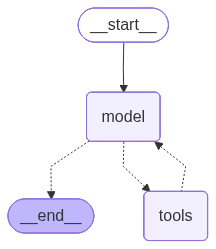

In [8]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
import os

llm = ChatOpenAI(
    model="gpt-4o", 
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=os.getenv("OPENAI_BASE_URL"),  
)

def get_weather(city: str) -> str:
    """Get the weather for a given city."""
    return f"The weather in {city} is sunny and warm."
agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

In [9]:
response = agent.invoke({"message": [{"role": "user", "content": "What is the weather in City: New York?"}]})

In [10]:
response["messages"][-1].content

'Here is the current weather in the mentioned cities:\n\n- **New York**: Sunny and warm.\n- **Los Angeles**: Sunny and warm.\n- **Chicago**: Sunny and warm.\n- **Miami**: Sunny and warm.\n- **Dallas**: Sunny and warm.'

In [11]:
agent.invoke({"message":"What is the weather in New York?"})

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 47, 'total_tokens': 109, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o', 'system_fingerprint': 'fp_246dab3317', 'id': 'chatcmpl-Do9PYWdFHRphllDkuQUsnzPuqNtOE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ea2a1-6b5a-75b2-8cc3-78274a2f7bcc-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Albuquerque'}, 'id': 'call_7qJW6KyjWDOKuG732YfO3nBw', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'city': 'Oakland'}, 'id': 'call_GgwRbBFccfkyHQEwtz3pBKhr', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'city': 'Omaha'}, 'id': 'call_DVvAsDDMPKsw8Uo0HKPsQPld', 'type': 'tool_ca

### tools

In [12]:
from langchain.chat_models import init_chat_model
model = init_chat_model("gpt-4.1")
response = model.invoke("Hi, how are you?")
print(response)

content="Hi! I'm just a language model, but I'm ready to help you. How can I assist you today?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 13, 'total_tokens': 35, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1', 'system_fingerprint': 'fp_6900ccfdf4', 'id': 'chatcmpl-Do9Pboek7eNcmp0jO9Yl1phfxLFaw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019ea2a1-73be-7dd3-94b7-dbcf0553d09b-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 13, 'output_tokens': 22, 'total_tokens': 35, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [13]:
from langchain.tools import tool
@tool
def get_weather(city: str) -> str:
    """Get the weather for a given city."""
    return f"The weather in {city} is sunny and warm."
model_with_tools = model.bind_tools([get_weather])
response = model_with_tools.invoke("What is the weather in New York?")
print(response)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 53, 'total_tokens': 68, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1', 'system_fingerprint': 'fp_27ae8fde8a', 'id': 'chatcmpl-Do9PbcppXL5sMkpJIyooovim9WkJJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019ea2a1-77d0-7200-a415-6a104a5012ba-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_uYOkoxFEUHmMFfqyYCy63yei', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 53, 'output_tokens': 15, 'total_tokens': 68, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [14]:
for tool_call in response.tool_calls:
    print(f"Tool called: {tool_call['name']} with arguments: {tool_call['args']}")

Tool called: get_weather with arguments: {'city': 'New York'}


In [15]:
# Tool execution loop
messages = [{"role": "user", "content": "What is the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

for tool_call in ai_msg.tool_calls:
    tool_result = get_weather.invoke(tool_call)
    print(f"Tool result: {tool_result}")
    messages.append(tool_result)
print(f"Messages after tool execution: {messages}")
final_response = model_with_tools.invoke(messages)
print(final_response.text)

Tool result: content='The weather in Boston is sunny and warm.' name='get_weather' tool_call_id='call_E9JPZwHkNnAmI6DXfykuYQFg'
Messages after tool execution: [{'role': 'user', 'content': 'What is the weather in Boston?'}, AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 52, 'total_tokens': 66, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1', 'system_fingerprint': 'fp_27ae8fde8a', 'id': 'chatcmpl-Do9PcTFWqf3sCkk4AKTOEja4u60Cy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ea2a1-79f9-71e0-96f3-4c44925de65d-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Boston'}, 'id': 'call_E9JPZwHkNnAmI6DXfykuYQFg', 'type': 'tool_call'}], invalid_tool_ca

### Middleware

In [16]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

agent = create_agent(
    model=model,
    # tools=[get_weather],
    # system_prompt="You are a helpful assistant.",
    middleware=[
        SummarizationMiddleware(
            model=model, 
            trigger=("messages", 10),
            keep = ("messages", 2)
            )
        ],
    checkpointer=InMemorySaver(),
)

In [17]:
# run with thread it
config = {
    "configurable": {"thread_id": "test-1"},
}

In [19]:
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-3?",
    "What is 7*6?",
]
for question in questions:
    response = agent.invoke({"messages": [HumanMessage(content=question)]}, config)
    print(f"messages: {response}")
    print(f"messages length: {len(response['messages'])}")

messages: {'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\n\nThe user is asking for solutions to basic arithmetic problems.\n\n## SUMMARY\n\nThe user has asked a series of simple arithmetic questions (addition, multiplication, division, subtraction), and the assistant has responded with correct answers for each.\n\n## ARTIFACTS\n\nNone\n\n## NEXT STEPS\n\nAnswer the user\'s latest arithmetic query: "What is 7*6?"', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='b93611a3-70b9-458e-b2cd-083538e15ceb'), AIMessage(content='7 * 6 = 42', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 104, 'total_tokens': 111, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'mod

In [20]:
@tool
def search_hotels(city: str) -> str:
    """Search hotels in a given city - returns long response to use more tokens."""
    return f"""Hotels in {city}:
1. Grand Hotel - 5 star, $200/night, spa, pool, gym
2. Budget Inn - 3 star, $50/night, free breakfast
3. City Lodge - 4 star, $120/night, gym, free wifi"""

In [32]:
agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model, 
            trigger=("tokens", 300),
            keep = ("tokens", 200)
            )
        ],
)

In [33]:
# run with thread it
config = {
    "configurable": {"thread_id": "test-1"},
}

def count_tokens(messages):
    total_chars = sum(len(str(msg.content)) for msg in messages)
    return total_chars// 4  # Approximate tokens as characters divided by 4

In [34]:
cities = ["New York", "Los Angeles", "Chicago"]
for city in cities:
    response = agent.invoke({"messages": [HumanMessage(content=f"Search hotels in {city}")]}, config)
    tokens = count_tokens(response["messages"])
    print(f"{city}: {tokens} tokens, {len(response['messages'])} messages")
    print(f"Response: {response['messages']}")

New York: 118 tokens, 4 messages
Response: [HumanMessage(content='Search hotels in New York', additional_kwargs={}, response_metadata={}, id='806ae6a3-67a1-4b6f-b5a4-4f50bcc8b0af'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 58, 'total_tokens': 74, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1', 'system_fingerprint': 'fp_b76fb08f92', 'id': 'chatcmpl-Do9hcw9qcohY99RndgOt9LFubCscr', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ea2b2-8262-72f0-ac6a-deff46503d7c-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'New York'}, 'id': 'call_O0aofITnNi7kc2Q18zvnGltb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens